# IsolationForest + ComplementNB × style_only - Best Hybrid Configuration

Notebook reproducing the **best hybrid detection configuration** from the unified benchmark.

| | |
|---|---|
| **Stage 1 (AD)** | IsolationForest (sklearn, dual one-class) |
| **Stage 2 (SL)** | ComplementNB (sklearn) on (s\_ai, s\_hum) |
| **Feature schema** | `style_only` (20 features) |
| **AD Scaler** | `QuantileTransformer` (uniform) |
| **Threshold** | `0.5184935` |
| **TS Macro-F1** | **0.7336** |

Hyperparameters are fully fixed. Running this notebook end-to-end reproduces the **0.7336** result on `test_sample`.

### Pipeline Architecture
```
style_only features (20-dim)
        │
        ▼
  [Stage 1]  Dual IsolationForest
             ├── mai  (trained on AI samples)
             └── mhum (trained on Human samples)
        │
        ▼  s_ai  = anomaly_score(x, mai)   ← how un-AI-like is x?
           s_hum = anomaly_score(x, mhum)  ← how un-Human-like is x?
        │
        ▼
  [Stage 2]  ComplementNB fitted on (s_ai, s_hum)
             → calibrated probability p(x = AI)
        │
        ▼
  [Stage 3]  Threshold τ = 0.5184935
             → final binary label
```

In [1]:
# =============================================================================
# CELL 1 - Imports
# =============================================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")
print("✅ Imports done")

✅ Imports done


In [2]:
# =============================================================================
# CELL 2 - Configuration & Feature Schema
# =============================================================================

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/doandangphuongnam/sem-eval-2026-task-a-feature-data"   # ← update if needed
OUTPUT_DIR = "if_cnb_style_only_output"
os.makedirs(os.path.join(OUTPUT_DIR, "submissions"), exist_ok=True)

RANDOM_STATE = 42
LABEL_COL    = "label"

# ── Feature schema: style_only (20 features) ──────────────────────────────────
FEAT_COLS = [
    "comment_ratio", "blank_line_ratio", "indentation_std", "line_len_std",
    "style_consistency", "ttr", "comment_completeness", "blank_per_function",
    "comment_per_function", "trailing_ws_ratio", "naming_uniformity",
    "line_len_burstiness", "token_entropy", "inline_comment_ratio", "keyword_density",
    "max_nesting_depth", "avg_block_length", "cyclomatic_proxy",
    "comment_word_count_avg", "function_size_regularity",
]

# ── Stage 1: IsolationForest hyperparameters ──────────────────────────────────
IF_PARAMS = {
    "n_estimators":  354,
    "contamination": 0.2080300112916018,
    "max_features":  14,
    "max_samples":   7585,
    "bootstrap":     False,
    "n_jobs":        1,
    "random_state":  42,
    "verbose":       0,
    "warm_start":    False,
}

# ── Stage 2: ComplementNB hyperparameters ─────────────────────────────────────
CNB_PARAMS = {
    "alpha":       0.019534440564903173,
    "class_prior": None,
    "fit_prior":   True,
    "force_alpha": True,
    "norm":        False,
}

# ── Decision threshold ────────────────────────────────────────────────────────
THRESHOLD = 0.5184935

print(f"✅ Config done — {len(FEAT_COLS)} features, threshold = {THRESHOLD}")

✅ Config done — 20 features, threshold = 0.5184935


In [3]:
# =============================================================================
# CELL 3 - Load Data
# =============================================================================
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
ts_df    = pd.read_csv(os.path.join(DATA_DIR, "test_sample.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

y_train = train_df[LABEL_COL].astype(int)
y_val   = val_df[LABEL_COL].astype(int)
y_ts    = ts_df[LABEL_COL].astype(int)

print(f"train       : {train_df.shape}  | label dist: {y_train.value_counts().to_dict()}")
print(f"val         : {val_df.shape}")
print(f"test_sample : {ts_df.shape}    | label dist: {y_ts.value_counts().to_dict()}")
print(f"test        : {test_df.shape}")
print("✅ Data loaded")

train       : (500000, 39)  | label dist: {1: 261525, 0: 238475}
val         : (100000, 39)
test_sample : (1000, 39)    | label dist: {0: 777, 1: 223}
test        : (500000, 37)
✅ Data loaded


In [4]:
# =============================================================================
# CELL 4 - Utilities
# =============================================================================

def make_preprocessor():
    imp = SimpleImputer(strategy="median")
    sc  = QuantileTransformer(output_distribution="uniform", n_quantiles=1000,
                              random_state=RANDOM_STATE)
    return imp, sc

def prep(df, feat_cols, imp, sc, fit=False):
    X = df[feat_cols].values
    if fit:
        imp.fit(X)
        sc.fit(imp.transform(X))
    return sc.transform(imp.transform(X))

def scale_anomaly(raw: np.ndarray) -> np.ndarray:
    """Flip sklearn decision_function: higher = more anomalous (1 = most anomalous)."""
    lo, hi = raw.min(), raw.max()
    return np.zeros_like(raw) if hi == lo else 1.0 - (raw - lo) / (hi - lo)

def get_stage1_scores(mai, mhum, imp, sc, df, feat_cols):
    """Return (s_ai, s_hum) for a dataframe — both in [0, 1]."""
    X     = sc.transform(imp.transform(df[feat_cols].values))
    s_ai  = scale_anomaly(mai.decision_function(X))
    s_hum = scale_anomaly(mhum.decision_function(X))
    return s_ai, s_hum

def get_hybrid_scores(mai, mhum, clf, imp, sc, df, feat_cols):
    """Run full hybrid pipeline → calibrated probability of AI label."""
    s_ai, s_hum = get_stage1_scores(mai, mhum, imp, sc, df, feat_cols)
    X_sl = np.column_stack([s_ai, s_hum])
    return clf.predict_proba(X_sl)[:, 1]

print("✅ Utilities defined")

✅ Utilities defined


In [5]:
# =============================================================================
# CELL 5 - Train Stage 1: IsolationForest (dual one-class)
# =============================================================================
imp, sc = make_preprocessor()
Xtr = prep(train_df, FEAT_COLS, imp, sc, fit=True)
ytr = y_train.values

Xai  = Xtr[ytr == 1]
Xhum = Xtr[ytr == 0]

mai  = IsolationForest(
    **{**IF_PARAMS, "max_samples": min(IF_PARAMS["max_samples"], len(Xai))}
)
mhum = IsolationForest(
    **{**IF_PARAMS, "max_samples": min(IF_PARAMS["max_samples"], len(Xhum))}
)
mai.fit(Xai)
mhum.fit(Xhum)

print("✅ Stage 1 models trained")
print(f"   AI model    — fitted on {len(Xai)} samples")
print(f"   Human model — fitted on {len(Xhum)} samples")

✅ Stage 1 models trained
   AI model    — fitted on 261525 samples
   Human model — fitted on 238475 samples


In [6]:
# =============================================================================
# CELL 6 - Train Stage 2: ComplementNB on (s_ai, s_hum)
# =============================================================================
# Compute 2-D anomaly-score representation for the full training set
s_ai_tr, s_hum_tr = get_stage1_scores(mai, mhum, imp, sc, train_df, FEAT_COLS)
X_sl_tr = np.column_stack([s_ai_tr, s_hum_tr])   # shape (n_train, 2)

# ComplementNB expects non-negative inputs; scores are already in [0, 1]
clf = ComplementNB(**CNB_PARAMS)
clf.fit(X_sl_tr, ytr)

print("✅ Stage 2 (ComplementNB) fitted on training anomaly scores")
print(f"   Input shape : {X_sl_tr.shape}  (s_ai, s_hum)")

✅ Stage 2 (ComplementNB) fitted on training anomaly scores
   Input shape : (500000, 2)  (s_ai, s_hum)


In [7]:
# =============================================================================
# CELL 7 - Evaluation
# =============================================================================
SPLITS = [
    ("train",       train_df, y_train),
    ("val",         val_df,   y_val),
    ("test_sample", ts_df,    y_ts),
]

print("=" * 60)
print("IsolationForest + ComplementNB × style_only — Results")
print("=" * 60)
print(f"  {'Split':<14}  {'Acc':>7}  {'Macro-F1':>9}  {'AUC':>7}")
print("  " + "─" * 42)

eval_rows = []
for split_name, split_df, y_true in SPLITS:
    scores = get_hybrid_scores(mai, mhum, clf, imp, sc, split_df, FEAT_COLS)
    preds  = (scores >= THRESHOLD).astype(int)
    acc    = accuracy_score(y_true, preds)
    f1     = f1_score(y_true, preds, average="macro", zero_division=0)
    try:    auc = roc_auc_score(y_true, scores)
    except: auc = float("nan")
    print(f"  {split_name:<14}  {acc:>7.4f}  {f1:>9.4f}  {auc:>7.4f}")
    eval_rows.append({"split": split_name, "acc": round(acc, 4),
                      "macro_f1": round(f1, 4), "auc": round(auc, 4)})

pd.DataFrame(eval_rows).to_csv(os.path.join(OUTPUT_DIR, "eval_results.csv"), index=False)
print("\n✅ Results saved → eval_results.csv")

IsolationForest + ComplementNB × style_only — Results
  Split               Acc   Macro-F1      AUC
  ──────────────────────────────────────────
  train            0.7120     0.6959   0.9333
  val              0.7061     0.6887   0.9294
  test_sample      0.8070     0.7336   0.7653

✅ Results saved → eval_results.csv


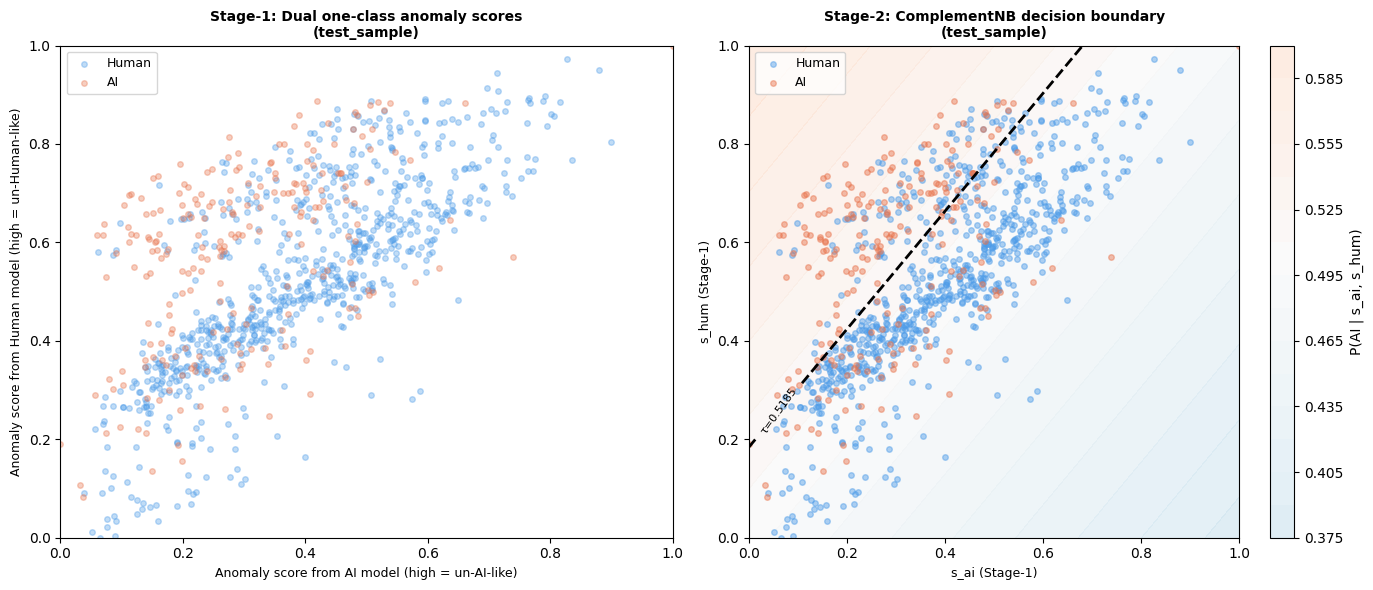

✅ Visualisation saved → decision_space.png


In [8]:
# =============================================================================
# CELL 8 - Visualisation: Stage-1 decision space + Stage-2 boundary
# =============================================================================
s_ai_ts, s_hum_ts = get_stage1_scores(mai, mhum, imp, sc, ts_df, FEAT_COLS)
scores_ts = get_hybrid_scores(mai, mhum, clf, imp, sc, ts_df, FEAT_COLS)

is_ai  = y_ts.values == 1
is_hum = y_ts.values == 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Stage-1 anomaly-score scatter ──────────────────────────────────────
ax = axes[0]
ax.scatter(s_ai_ts[is_hum], s_hum_ts[is_hum],
           c="#4C9BE8", alpha=0.35, s=16, label="Human", rasterized=True)
ax.scatter(s_ai_ts[is_ai],  s_hum_ts[is_ai],
           c="#E8734C", alpha=0.35, s=16, label="AI",    rasterized=True)
ax.set_xlabel("Anomaly score from AI model (high = un-AI-like)", fontsize=9)
ax.set_ylabel("Anomaly score from Human model (high = un-Human-like)", fontsize=9)
ax.set_title("Stage-1: Dual one-class anomaly scores\n(test_sample)",
             fontsize=10, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc="upper left")

# ── Right: Stage-2 probability heatmap + scatter ──────────────────────────────
ax2 = axes[1]
# Build a probability grid via ComplementNB
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid_pts  = np.column_stack([grid_x.ravel(), grid_y.ravel()])
grid_prob = clf.predict_proba(grid_pts)[:, 1].reshape(200, 200)

im = ax2.contourf(grid_x, grid_y, grid_prob, levels=20,
                  cmap="RdBu_r", alpha=0.55, vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, label="P(AI | s_ai, s_hum)")

# Decision boundary at THRESHOLD
cs = ax2.contour(grid_x, grid_y, grid_prob, levels=[THRESHOLD],
                 colors="black", linewidths=2, linestyles="--")
ax2.clabel(cs, fmt=f"τ={THRESHOLD:.4f}", fontsize=8)

ax2.scatter(s_ai_ts[is_hum], s_hum_ts[is_hum],
            c="#4C9BE8", alpha=0.45, s=16, label="Human", rasterized=True)
ax2.scatter(s_ai_ts[is_ai],  s_hum_ts[is_ai],
            c="#E8734C", alpha=0.45, s=16, label="AI",    rasterized=True)

ax2.set_xlabel("s_ai (Stage-1)", fontsize=9)
ax2.set_ylabel("s_hum (Stage-1)", fontsize=9)
ax2.set_title("Stage-2: ComplementNB decision boundary\n(test_sample)",
              fontsize=10, fontweight="bold")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "decision_space.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisation saved → decision_space.png")

In [9]:
# =============================================================================
# CELL 9 - Generate Submission File
# =============================================================================
scores_te = get_hybrid_scores(mai, mhum, clf, imp, sc, test_df, FEAT_COLS)
preds_te  = (scores_te >= THRESHOLD).astype(int)

test_ids = test_df["ID"] if "ID" in test_df.columns else pd.RangeIndex(len(test_df))
sub_df   = pd.DataFrame({"ID": test_ids, "label": preds_te})

sub_path = os.path.join(OUTPUT_DIR, "submissions", "submission_HY_IF_CNB_style_only.csv")
sub_df.to_csv(sub_path, index=False)

print(f"✅ Submission saved → {sub_path}")
print(f"   Predictions : {dict(pd.Series(preds_te).value_counts().sort_index())}")
print(sub_df.head())

✅ Submission saved → if_cnb_style_only_output/submissions/submission_HY_IF_CNB_style_only.csv
   Predictions : {0: np.int64(389784), 1: np.int64(110216)}
   ID  label
0   0      0
1   2      0
2   5      0
3   6      0
4   7      0
